# 앙상블 & 스태킹

**기반 모델**: v2 (전체기간 + Return 피처) — LR, XGBoost, MLP, Dilated TCN

| 방법 | 설명 |
|------|------|
| Simple Ensemble | 4개 모델 예측 확률 단순 평균 |
| Weighted Ensemble | Val 기준 최적 가중치 탐색 |
| Stacking | Val 예측값을 피처로 메타 모델(LR) 학습 |

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import warnings
warnings.filterwarnings("ignore")

from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
np.random.seed(42)

RESULTS_DIR = Path("../reports/results/v2")
FIG_DIR     = Path("../reports/figures")
ENS_DIR     = Path("../reports/results/ensemble")
ENS_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["lr", "xgb", "mlp", "tcn"]
MODEL_NAMES = {"lr": "LR", "xgb": "XGBoost", "mlp": "MLP", "tcn": "Dilated TCN"}

# val/test 예측 로드
val_preds  = {m: pd.read_csv(RESULTS_DIR / f"{m}_val_predictions.csv",  index_col=0, parse_dates=True) for m in MODELS}
test_preds = {m: pd.read_csv(RESULTS_DIR / f"{m}_test_predictions.csv", index_col=0, parse_dates=True) for m in MODELS}

# TCN은 window=20 때문에 인덱스가 짧음 → 공통 인덱스 사용
val_idx  = val_preds["tcn"].index
test_idx = test_preds["tcn"].index

# 공통 인덱스로 정렬
val_prob  = np.stack([val_preds[m].loc[val_idx,  "y_prob"].values for m in MODELS], axis=1)
test_prob = np.stack([test_preds[m].loc[test_idx, "y_prob"].values for m in MODELS], axis=1)
y_val  = val_preds["tcn"].loc[val_idx,  "y_true"].values
y_test = test_preds["tcn"].loc[test_idx, "y_true"].values

majority = max(y_test.mean(), 1 - y_test.mean()) * 100
print(f"Val 샘플: {len(y_val)}, Test 샘플: {len(y_test)}")
print(f"Test Majority baseline: {majority:.1f}%")

all_metrics = []

Val 샘플: 230, Test 샘플: 205
Test Majority baseline: 53.2%


In [2]:
def evaluate(name, y_true, y_pred, y_prob):
    """모델 성능 지표를 딕셔너리로 반환한다."""
    return {
        "model":     name,
        "accuracy":  round(accuracy_score(y_true, y_pred) * 100, 2),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall":    round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1":        round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc":   round(roc_auc_score(y_true, y_prob), 4),
    }

def best_threshold(y_true, y_prob):
    """Val 기준 F1 최대 임계값을 탐색한다."""
    best_t, best_f1 = 0.5, 0
    for t in np.arange(0.3, 0.71, 0.01):
        f1 = f1_score(y_true, (y_prob > t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return round(best_t, 2)

# 개별 모델 기준 성능
print("=== 개별 모델 Test 성능 (공통 인덱스 기준) ===")
for i, m in enumerate(MODELS):
    prob = test_prob[:, i]
    t = best_threshold(y_val, val_prob[:, i])
    pred = (prob > t).astype(int)
    met = evaluate(MODEL_NAMES[m], y_test, pred, prob)
    print(f"  {m}: Accuracy={met['accuracy']}%  ROC-AUC={met['roc_auc']}")

=== 개별 모델 Test 성능 (공통 인덱스 기준) ===
  lr: Accuracy=53.66%  ROC-AUC=0.5691
  xgb: Accuracy=53.17%  ROC-AUC=0.5161
  mlp: Accuracy=53.17%  ROC-AUC=0.5642
  tcn: Accuracy=54.63%  ROC-AUC=0.5728


## 1. Simple Ensemble — 단순 평균

In [3]:
# Val로 임계값 탐색
val_avg  = val_prob.mean(axis=1)
test_avg = test_prob.mean(axis=1)

t = best_threshold(y_val, val_avg)
pred = (test_avg > t).astype(int)
m = evaluate("Simple Ensemble", y_test, pred, test_avg)
all_metrics.append(m)
print(f"임계값={t}  Accuracy={m['accuracy']}%  F1={m['f1']}  ROC-AUC={m['roc_auc']}")

임계값=0.3  Accuracy=53.17%  F1=0.6943  ROC-AUC=0.579


## 2. Weighted Ensemble — Val 기준 최적 가중치

In [4]:
# 가중치 그리드 탐색 (4개 모델, 합계=1)
best_roc, best_weights = 0, [0.25, 0.25, 0.25, 0.25]

steps = np.arange(0, 1.1, 0.1)
for w in product(steps, repeat=4):
    if abs(sum(w) - 1.0) > 0.01:
        continue
    w = np.array(w)
    prob_w = (val_prob * w).sum(axis=1)
    roc = roc_auc_score(y_val, prob_w)
    if roc > best_roc:
        best_roc = roc
        best_weights = w

print(f"최적 가중치: LR={best_weights[0]:.1f}  XGB={best_weights[1]:.1f}  MLP={best_weights[2]:.1f}  TCN={best_weights[3]:.1f}")
print(f"Val ROC-AUC: {best_roc:.4f}")

test_weighted = (test_prob * best_weights).sum(axis=1)
t = best_threshold(y_val, (val_prob * best_weights).sum(axis=1))
pred = (test_weighted > t).astype(int)
m = evaluate("Weighted Ensemble", y_test, pred, test_weighted)
all_metrics.append(m)
print(f"임계값={t}  Accuracy={m['accuracy']}%  F1={m['f1']}  ROC-AUC={m['roc_auc']}")

최적 가중치: LR=0.6  XGB=0.0  MLP=0.3  TCN=0.1
Val ROC-AUC: 0.5533
임계값=0.3  Accuracy=53.17%  F1=0.6943  ROC-AUC=0.5922


## 3. Stacking — 메타 모델 (Logistic Regression)

In [5]:
# Val 예측 확률을 메타 피처로 사용
# 메타 모델: Val로 학습 → Test 평가
# (주의: Val 샘플 수가 적어 과적합 가능성 있음 — 결과 해석 시 참고)

scaler_meta = StandardScaler()
X_meta_train = scaler_meta.fit_transform(val_prob)   # val 예측 확률
X_meta_test  = scaler_meta.transform(test_prob)       # test 예측 확률

best_roc, best_C, best_meta = 0, 1, None
for C in [0.001, 0.01, 0.1, 1, 10]:
    meta = LogisticRegression(C=C, max_iter=1000, random_state=42)
    meta.fit(X_meta_train, y_val)
    prob_v = meta.predict_proba(X_meta_train)[:, 1]
    roc = roc_auc_score(y_val, prob_v)
    if roc > best_roc:
        best_roc, best_C, best_meta = roc, C, meta

print(f"메타 모델 최적 C={best_C}  (val ROC-AUC={best_roc:.4f})")
print(f"메타 모델 가중치: LR={best_meta.coef_[0][0]:.3f}  XGB={best_meta.coef_[0][1]:.3f}  "
      f"MLP={best_meta.coef_[0][2]:.3f}  TCN={best_meta.coef_[0][3]:.3f}")

test_stack_prob = best_meta.predict_proba(X_meta_test)[:, 1]
t = best_threshold(y_val, best_meta.predict_proba(X_meta_train)[:, 1])
pred = (test_stack_prob > t).astype(int)
m = evaluate("Stacking (LR meta)", y_test, pred, test_stack_prob)
all_metrics.append(m)
print(f"임계값={t}  Accuracy={m['accuracy']}%  F1={m['f1']}  ROC-AUC={m['roc_auc']}")

메타 모델 최적 C=0.01  (val ROC-AUC=0.5765)
메타 모델 가중치: LR=0.008  XGB=-0.038  MLP=-0.000  TCN=0.072
임계값=0.3  Accuracy=53.17%  F1=0.6943  ROC-AUC=0.5737


## 4. 결과 비교

In [6]:
# 개별 모델 v2 성능 로드
v2_metrics = pd.read_csv(Path("../reports/results/v2/model_metrics.csv"))
v2_metrics["type"] = "개별 모델"

ens_metrics = pd.DataFrame(all_metrics)
ens_metrics["type"] = "앙상블/스태킹"

all_results = pd.concat([
    v2_metrics[["model", "accuracy", "roc_auc", "type"]],
    ens_metrics[["model", "accuracy", "roc_auc", "type"]],
], ignore_index=True)

ens_metrics.to_csv(ENS_DIR / "ensemble_metrics.csv", index=False)

print("=" * 55)
print("전체 결과 비교 (Test 기준)")
print("=" * 55)
print(all_results.to_string(index=False))
print(f"\nMajority baseline: {majority:.1f}%")

전체 결과 비교 (Test 기준)
             model  accuracy  roc_auc    type
                LR     52.89   0.5763   개별 모델
           XGBoost     52.00   0.4955   개별 모델
               MLP     52.44   0.5570   개별 모델
        DilatedTCN     54.63   0.5728   개별 모델
   Simple Ensemble     53.17   0.5790 앙상블/스태킹
 Weighted Ensemble     53.17   0.5922 앙상블/스태킹
Stacking (LR meta)     53.17   0.5737 앙상블/스태킹

Majority baseline: 53.2%


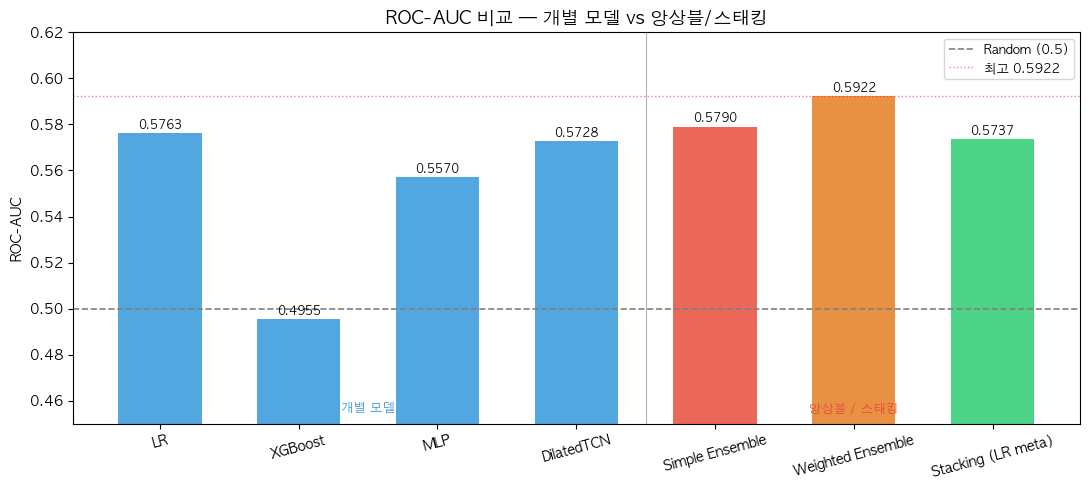

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))

colors = ["#3498db"] * 4 + ["#e74c3c", "#e67e22", "#2ecc71"]
bars = ax.bar(all_results["model"], all_results["roc_auc"], color=colors, alpha=0.85, width=0.6)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.2, label="Random (0.5)")
ax.axhline(all_results["roc_auc"].max(), color="red", linestyle=":",
           linewidth=1, alpha=0.5, label=f"최고 {all_results['roc_auc'].max():.4f}")

for bar, val in zip(bars, all_results["roc_auc"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=8.5)

ax.set_title("ROC-AUC 비교 — 개별 모델 vs 앙상블/스태킹", fontsize=13)
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.45, 0.62)
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=15)

# 구분선
ax.axvline(3.5, color="black", linewidth=0.8, linestyle="-", alpha=0.3)
ax.text(1.5, 0.455, "개별 모델", ha="center", fontsize=9, color="#3498db")
ax.text(5.0, 0.455, "앙상블 / 스태킹", ha="center", fontsize=9, color="#e74c3c")

plt.tight_layout()
plt.savefig(FIG_DIR / "ensemble_comparison.png", dpi=150, bbox_inches="tight")
plt.show()